<a href="https://colab.research.google.com/github/Harss3/Pyhton-Exercise/blob/main/%5BKlasifikasi%5D_Submission_Akhir_BMLP_Your_Name.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Collabs ML/spent_cluster.csv')
df.head()

,Category,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Days,Target
0,4,1,1.28,1.28,2,1,5270400000000000,0
1,3,2,74.69,149.39,2,0,53568000000000000,0
2,1,1,76.06,76.06,3,1,34041600000000000,0
3,0,5,11.24,56.18,0,0,30326400000000000,0
4,3,3,43.71,131.12,2,0,46224000000000000,0


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [3]:
x = df.drop(['Target'], axis=1)
y = df['Target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [9]:
# menggunakan model klasifikasi Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [59]:
# menggunakan model klasifikasi Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

Tulis narasi atau penjelasan algoritma yang Anda gunakan.

**Model Decision Tree Classifier:** merupakan model machine learning yang digunakan dalam klasifikasi. Model ini bekerja layaknya pohon yang menumbuhkan banyak cabang ranting dan daun untuk membuat keputusan-keputusan pada data. Pembagian data ke dalam subset berdasarkan fitur-fitur tertentu dapat diumpamakan seperti ranting yang terus melakukan percabangan, sementara ujung daunnya terbentuk melalui hasil keputusan. Wujud strukturnya yang mirip dengan pengambilan keputusan alami membuat model ini lebih mudah dipahami dan diinterpretasikan.

**Model Random Forest Classifier:** merupakan model machine learning yang terdiri dari banyak pohon keputusan. Cara kerjanya hampir sama dengan Decision Tree, namun model ini bekerja dengan cara mengumpulkan keputusan-keputusan dari tiap pohon keputusan kemudian mengambil suara terbanyak dari pohon keputusan untuk memprediksi nilai akhirnya. Model ini memiliki keunggulan dalam menghasilkan akurasi yang lebih tinggi dibandingkan dengan pohon keputusan tunggal. Keunggulan lainnya adalah model ini lebih tahan terhadap outlier, namun biasanya model ini bekerja lebih lambat jika berhadapan dengan data besar.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [10]:
# prediksi untuk Random Forest
ypred_rf = rf.predict(x_test)
print(f'Nilai prediksi Random Forest: {ypred_rf}')
print(f'Skor data training Random Forest: {rf.score(x_train, y_train)}')
print(f'Skor data testing Random Forest: {rf.score(x_test, y_test)}')

Nilai prediksi Random Forest: [0 0 0 ... 0 0 0]
Skor data training Random Forest: 1.0
Skor data testing Random Forest: 0.9995


In [12]:
# prediksi untuk Decision Tree
ypred_dtree = dtree.predict(x_test)
print(f'Nilai prediksi Decision Tree: {ypred_dtree}')
print(f'Skor data training Decision Tree: {dtree.score(x_train, y_train)}')
print(f'Skor data testing Decision Tree: {dtree.score(x_test, y_test)}')

Nilai prediksi Decision Tree: [0 0 0 ... 0 0 0]
Skor data training Decision Tree: 1.0
Skor data testing Decision Tree: 1.0


In [36]:
# mengevaluasi model Random Forest dengan matrices
print(f'Nilai akurasi Random Forest: {accuracy_score(y_test, ypred_rf):.4f}')
print(f'Nilai presisi Random Forest: {precision_score(y_test, ypred_rf):.4f}')
print(f'Nilai Recall Random Forest: {recall_score(y_test, ypred_rf):.4f}')
print(f'Nilai F1-score Random Forest: {f1_score(y_test, ypred_rf):.4f}')

Nilai akurasi Random Forest: 0.9995
Nilai presisi Random Forest: 0.9762
Nilai Recall Random Forest: 1.0000
Nilai F1-score Random Forest: 0.9880


In [14]:
# mengevaluasi model Decision Tree dengan matrices
print(f'Nilai akurasi Decision Tree: {accuracy_score(y_test, ypred_dtree)}')
print(f'Nilai presisi Decision Tree: {precision_score(y_test, ypred_dtree)}')
print(f'Nilai Recall Decision Tree: {recall_score(y_test, ypred_dtree)}')
print(f'Nilai F1-score Decision Tree: {f1_score(y_test, ypred_dtree)}')

Nilai akurasi Decision Tree: 1.0
Nilai presisi Decision Tree: 1.0
Nilai Recall Decision Tree: 1.0
Nilai F1-score Decision Tree: 1.0


In [15]:
# hasil skor sebelum tuning parameter
print(f'Skor Random Forest sebelum tuning parameter: {rf.score(x_test, y_test)}')
print(f'Skor Decision Tree sebelum tuning parameter: {dtree.score(x_test, y_test)}')

Skor Random Forest sebelum tuning parameter: 0.9995
Skor Decision Tree sebelum tuning parameter: 1.0


Confusion Matrix Random Forest: 
[[1958    1]
 [   0   41]]
True Negative: 1958
False Positive: 1
False Negative: 0
True Positive: 41


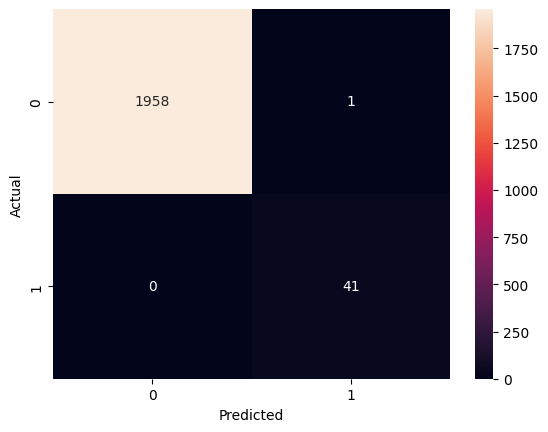

In [17]:
# confusion matrix Random Forest
cm_rf = confusion_matrix(y_test, ypred_rf)
print(f'Confusion Matrix Random Forest: \n{cm_rf}')
tn, fp, fn, tp = cm_rf.ravel()
print(f'True Negative: {tn}')
print(f'False Positive: {fp}')
print(f'False Negative: {fn}')
print(f'True Positive: {tp}')
sb.heatmap(cm_rf, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Confusion Matrix Decision Tree: 
[[1959    0]
 [   0   41]]
True Negative: 1959
False Positive: 0
False Negative: 0
True Positive: 41


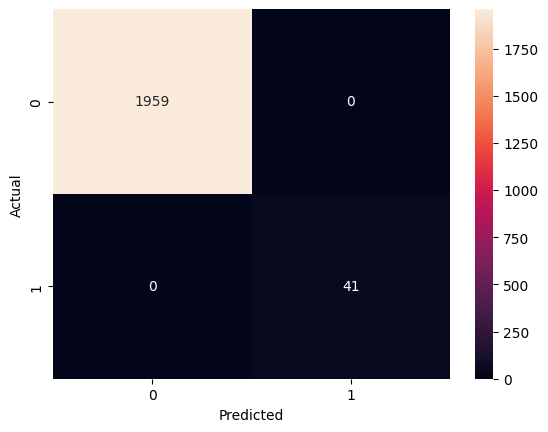

In [19]:
# confusion matrix Decision Tree
cm_dtree = confusion_matrix(y_test, ypred_dtree)
print(f'Confusion Matrix Decision Tree: \n{cm_dtree}')
tn, fp, fn, tp = cm_dtree.ravel()
print(f'True Negative: {tn}')
print(f'False Positive: {fp}')
print(f'False Negative: {fn}')
print(f'True Positive: {tp}')
sb.heatmap(cm_dtree, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

Berdasarkan hasil evaluasi di atas, model Decision Tree cenderung memiliki perolehan nilai yang lebih tinggi dari model Random Forest dikarenakan model Decision Tree dapat bekerja dengan baik tanpa mempertimbangkan hubungan linear antara fitur maupun target sehingga lebih mampu dalam mengatasi hubungan nonliear.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [20]:
# mencari kombinasi parameter menggunakan gridsearch

# parameter tuning untuk Random Forest
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10,20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_rf, cv=3, verbose=2, n_jobs=-1)
grid_rf.fit(x_train, y_train)
print(f'Parameter terbaik untuk Random Forest: {grid_rf.best_params_}')

# evaluasi model tuning Random Forest
rf_estimator = grid_rf.best_estimator_
gscore_rf = rf_estimator.score(x_test, y_test)
print(f'Skor hyperparameter tuning pada Random Forest: {gscore_rf}')

Fitting 3 folds for each of 162 candidates, totalling 486 fits
Parameter terbaik untuk Random Forest: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Skor hyperparameter tuning pada Random Forest: 0.9995


In [22]:
# parameter tuning untuk Decision Tree
param_dtree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dtree = GridSearchCV(estimator=dtree, param_grid=param_dtree, cv=3, verbose=2, n_jobs=-1)
grid_dtree.fit(x_train, y_train)
print(f'Parameter terbaik untuk Decision Tree: {grid_dtree.best_params_}')

# evaluasi model tuning Decision Tree
dtree_estimator = grid_dtree.best_estimator_
gscore_dtree = dtree_estimator.score(x_test, y_test)
print(f'Skor hyperparameter tuning pada Decision Tree: {gscore_dtree}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Parameter terbaik untuk Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Skor hyperparameter tuning pada Decision Tree: 1.0


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [39]:
# evaluasi model Random Forest setelah tuning
rf_after = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=1, min_samples_split=2, criterion='gini')
rf_after.fit(x_train, y_train)
ypred_rf_after = rf_after.predict(x_test)

print(f'Nilai training set Random Forest setelah tuning: {rf_after.score(x_train, y_train)}')
print(f'Nilai testing set Random Forest setelah tuning: {rf_after.score(x_test, y_test)}')

print('\n')
print(f'Nilai akurasi Random Forest setelah tuning: {accuracy_score(y_test, ypred_rf_after)}')
print(f'Nilai presisi Random Forest setelah tuning: {precision_score(y_test, ypred_rf_after):.4f}')
print(f'Nilai Recall Random Forest setelah tuning: {recall_score(y_test, ypred_rf_after)}')
print(f'Nilai F1-score Random Forest setelah tuning: {f1_score(y_test, ypred_rf_after):.4f}')

Nilai training set Random Forest setelah tuning: 1.0
Nilai testing set Random Forest setelah tuning: 0.9995


Nilai akurasi Random Forest setelah tuning: 0.9995
Nilai presisi Random Forest setelah tuning: 0.9762
Nilai Recall Random Forest setelah tuning: 1.0
Nilai F1-score Random Forest setelah tuning: 0.9880


In [26]:
# evaluasi model Decision Tree setelah tuning
dtree_after = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_leaf=1, min_samples_split=2)
dtree_after.fit(x_train, y_train)
ypred_dtree_after = dtree_after.predict(x_test)

print(f'Nilai training set Decision Tree setelah tuning: {dtree_after.score(x_train, y_train)}')
print(f'Nilai testing set Decision Tree setelah tuning: {dtree_after.score(x_test, y_test)}')

print('\n')
print(f'Nilai akurasi Decision Tree setelah tuning: {accuracy_score(y_test, ypred_dtree_after)}')
print(f'Nilai presisi Decision Tree setelah tuning: {precision_score(y_test, ypred_dtree_after)}')
print(f'Nilai Recall Decision Tree setelah tuning: {recall_score(y_test, ypred_dtree_after)}')
print(f'Nilai F1-score Decision Tree setelah tuning: {f1_score(y_test, ypred_dtree_after)}')

Nilai training set Decision Tree setelah tuning: 1.0
Nilai testing set Decision Tree setelah tuning: 1.0


Nilai akurasi Decision Tree setelah tuning: 1.0
Nilai presisi Decision Tree setelah tuning: 1.0
Nilai Recall Decision Tree setelah tuning: 1.0
Nilai F1-score Decision Tree setelah tuning: 1.0


## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.

========================================================

**Analisa Hasil**

1. Perbandingan hasil evaluasi sebelum dan setelah tuning tidak jauh berbeda dari kedua model yang diterapkan di atas. Nilai akurasi dan F1-score dari kedua model mencapai presentase yang tinggi.

2. Nilai dari precision dan recall pada kedua model berada di presentase yang tinggi yang menunjukkan model bekerja begitu baik pada Binary Classification, namun jika mengacu pada teori machine learning dalam perkara overfitting dan underfitting, hasil evaluasi yang diperoleh menunjukkan bahwa model dapat mengalami underfitting dikarenakan skor training set dan test set yang hampir sama satu sama lain.

3. Untuk menangani kasus underfitting yang bisa saja terjadi pada model, maka teknik yang dapat digunakan dalam kedua model ini adalah teknik pruning yang artinya memangkas ranting dan cabang pada kedua model

In [54]:
# menerapkan teknik pruning pada Random Forest
rf_pruning = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=1, min_samples_split=2, criterion='gini')
rf_pruning.fit(x_train, y_train)

ypred_rf_pruning = rf_pruning.predict(x_test)
print(f'Nilai training set Random Forest setelah pruning: {rf_pruning.score(x_train, y_train)}')
print(f'Nilai testing set Random Forest setelah pruning: {rf_pruning.score(x_test, y_test)}')

print('\n')
print(f'Nilai akurasi Random Forest setelah pruning: {accuracy_score(y_test, ypred_rf_pruning)}')
print(f'Nilai presisi Random Forest setelah pruning: {precision_score(y_test, ypred_rf_pruning):.4f}')
print(f'Nilai Recall Random Forest setelah pruning: {recall_score(y_test, ypred_rf_pruning)}')
print(f'Nilai F1-score Random Forest setelah pruning: {f1_score(y_test, ypred_rf_pruning):.4f}')

Nilai training set Random Forest setelah pruning: 1.0
Nilai testing set Random Forest setelah pruning: 0.9995


Nilai akurasi Random Forest setelah pruning: 0.9995
Nilai presisi Random Forest setelah pruning: 0.9762
Nilai Recall Random Forest setelah pruning: 1.0
Nilai F1-score Random Forest setelah pruning: 0.9880


In [49]:
# menerapkan teknik pruning pada Decision Tree
dtree_pruning = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=1, min_samples_split=2)
dtree_pruning.fit(x_train, y_train)

ypred_dtree_pruning = dtree_pruning.predict(x_test)
print(f'Nilai training set Decision Tree setelah pruning: {dtree_pruning.score(x_train, y_train)}')
print(f'Nilai testing set Decision Tree setelah pruning: {dtree_pruning.score(x_test, y_test)}')

print('\n')
print(f'Nilai akurasi Decision Tree setelah pruning: {accuracy_score(y_test, ypred_dtree_pruning)}')
print(f'Nilai presisi Decision Tree setelah pruning: {precision_score(y_test, ypred_dtree_pruning)}')
print(f'Nilai Recall Decision Tree setelah pruning: {recall_score(y_test, ypred_dtree_pruning)}')
print(f'Nilai F1-score Decision Tree setelah pruning: {f1_score(y_test, ypred_dtree_pruning)}')

Nilai training set Decision Tree setelah pruning: 1.0
Nilai testing set Decision Tree setelah pruning: 1.0


Nilai akurasi Decision Tree setelah pruning: 1.0
Nilai presisi Decision Tree setelah pruning: 1.0
Nilai Recall Decision Tree setelah pruning: 1.0
Nilai F1-score Decision Tree setelah pruning: 1.0


In [58]:
# menerapkan cross validation untuk mengevaluasi kinerja model setelah pruning
from sklearn.model_selection import cross_val_score

print(f'Skor Cross Validation pada Random Forest setelah pruning: {cross_val_score(rf_pruning, x_train, y_train, cv=5)}')
print(f'Skor Cross Validation pada Decision Tree setelah pruning: {cross_val_score(dtree_pruning, x_train, y_train, cv=5)}')

Skor Cross Validation pada Random Forest setelah pruning: [0.999375 1.       1.       1.       1.      ]
Skor Cross Validation pada Decision Tree setelah pruning: [0.999375 0.999375 1.       1.       1.      ]


Setelah menerapkan teknik pruning untuk mengidentifikasi underfitting pada model ternyata hasil evaluasi tidak mengalami perubahan yang signifikan. Kondisi ini pun terlihat pada hasil dari cross validation score yang mengisyaratkan perolehan nilai yang mendekati maksimum. Maka berdasarkan nilai yang dapat diperoleh daripada hasil-hasil tersebut dapat ditarik kesimpulan bahwa model telah bekerja dengan baik pada dataset ini.